In [10]:
%pip install ta

Note: you may need to restart the kernel to use updated packages.


2026-07-30 11:22:43,245 [INFO] Bắt đầu tính toán Technical Indicators (sử dụng thư viện 'ta')...
2026-07-30 11:22:43,380 [INFO] Hoàn tất. Số lượng features: 19
2026-07-30 11:22:43,382 [INFO] Đã loại bỏ 49 dòng NaN ở đầu chuỗi dữ liệu.


Kích thước dữ liệu gốc: (2191, 5)
Kích thước dữ liệu sau khi thêm Features: (2142, 19)


,MACD_Signal,ADX,RSI_14,Stoch_k,ROC,BBU_20_2.0,BBL_20_2.0,ATR,OBV,CMF
Date,,,,,,,,,,
2025-12-27,-0.467720,23.905768,45.783535,48.863726,0.573875,279.372148,269.431221,3.993691,4.548665e+09,0.090804
2025-12-28,-0.518303,23.161560,45.783535,48.863726,0.444545,278.993425,269.361779,3.887381,4.548665e+09,0.097556
2025-12-29,-0.547938,22.713393,47.285069,73.941611,0.032890,278.698234,269.315605,3.753015,4.572380e+09,0.162852
2025-12-30,-0.572471,22.331552,44.763092,66.557628,-0.215607,278.020447,269.424448,3.613275,4.550241e+09,0.137152
2025-12-31,-0.610642,22.242464,40.581592,57.900858,-0.661391,277.456536,269.372502,3.492785,4.522947e+09,0.067203


Đã lưu bộ dữ liệu Feature tại: ../data/processed/AAPL_features.parquet


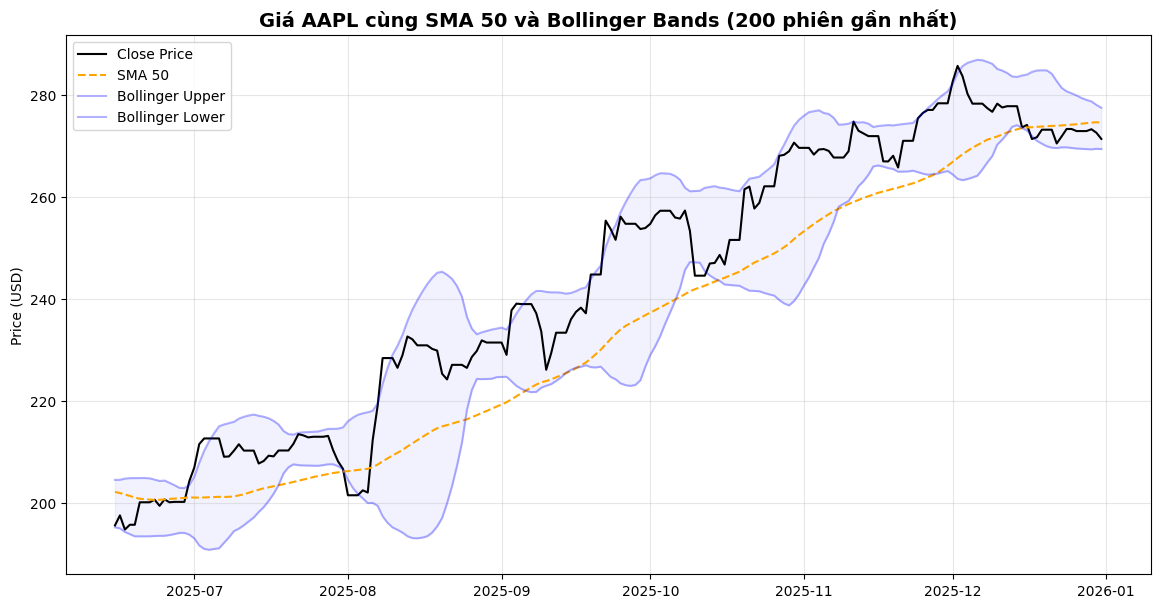

In [11]:
# Cell 1: Import
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.feature_engineer import TechnicalFeatures

# Tự động reload lại code nếu sửa file .py
%load_ext autoreload
%autoreload 2

# Cell 2: Đọc dữ liệu
df_clean = pd.read_parquet("../data/processed/AAPL_cleaned.parquet")
print("Kích thước dữ liệu gốc:", df_clean.shape)

# Cell 3: Sinh Feature Đặc trưng
te = TechnicalFeatures(df_clean)
df_features = te.generate_all_features()

print(f"Kích thước dữ liệu sau khi thêm Features: {df_features.shape}")
# Hiển thị 5 dòng, 10 cột cuối
display(df_features.iloc[-5:, -10:])

# Cell 4: Lưu dữ liệu để huấn luyện ML
output_path = "../data/processed/AAPL_features.parquet"
df_features.to_parquet(output_path)
print(f"Đã lưu bộ dữ liệu Feature tại: {output_path}")

# Cell 5: Trực quan hóa kiểm tra (Close, SMA50 và Bollinger Bands)
plt.figure(figsize=(14, 7))

# Lấy 200 ngày gần nhất để biểu đồ không bị quá dày đặc
plot_df = df_features.tail(200)

plt.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black', linewidth=1.5)
plt.plot(plot_df.index, plot_df['SMA_50'], label='SMA 50', color='orange', linestyle='--')
plt.plot(plot_df.index, plot_df['BBU_20_2.0'], label='Bollinger Upper', color='blue', alpha=0.3)
plt.plot(plot_df.index, plot_df['BBL_20_2.0'], label='Bollinger Lower', color='blue', alpha=0.3)
plt.fill_between(plot_df.index, plot_df['BBL_20_2.0'], plot_df['BBU_20_2.0'], color='blue', alpha=0.05)

plt.title("Giá AAPL cùng SMA 50 và Bollinger Bands (200 phiên gần nhất)", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()